Importer les données à l’aide de pandas.

In [41]:
import pandas as pd
import numpy as np


df = pd.read_csv("../data/raw/dataset-diabete.csv")



Comprendre la structure générale du jeu de données (types, dimensions, aperçus).

In [42]:
print(f"database shape : {df.shape[0]} lignes and {df.shape[1]} column \n")

display(df.head())

print(f"\n \ninfos for our dataset : \n ")
df.info()

database shape : 768 lignes and 9 column 



,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,6,148,72,35,0,33.6,0.627,50
1,1,1,85,66,29,0,26.6,0.351,31
2,2,8,183,64,0,0,23.3,0.672,32
3,3,1,89,66,23,94,28.1,0.167,21
4,4,0,137,40,35,168,43.1,2.288,33



 
infos for our dataset : 
 
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        768 non-null    int64  
 1   Pregnancies               768 non-null    int64  
 2   Glucose                   768 non-null    int64  
 3   BloodPressure             768 non-null    int64  
 4   SkinThickness             768 non-null    int64  
 5   Insulin                   768 non-null    int64  
 6   BMI                       768 non-null    float64
 7   DiabetesPedigreeFunction  768 non-null    float64
 8   Age                       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Identifier les valeurs manquantes et les doublons.

In [43]:
print("values nan : ")

display(df.isnull().sum())

doublons = df.duplicated().sum()

display(doublons)

if doublons > 0:
    df = df.drop_duplicates()
    print('we droped the duplicated values by succesfully')


values nan : 


ID                          0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

np.int64(0)

Analyser la distribution des variables numériques.

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,383.500000,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,221.846794,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,191.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,383.500000,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,575.250000,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,767.000000,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


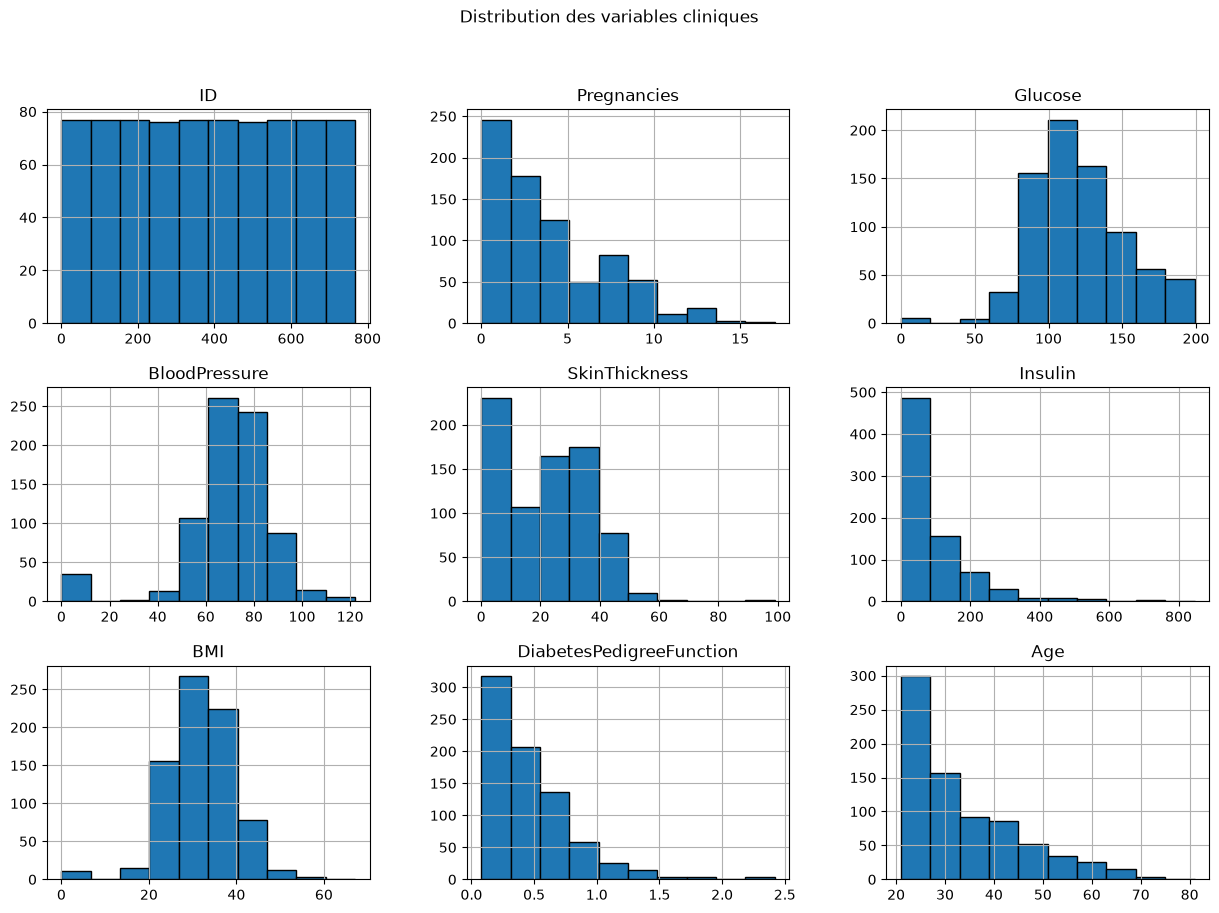

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

display(df.describe())

df.hist(figsize=(15, 10),edgecolor='black')

plt.suptitle('Distribution des variables cliniques')

plt.show()


## Étape 2 — Prétraitement des données - Gestion des valeurs manquantes et aberrantes

Identifier et traiter les valeurs manquantes dans le jeu de données si elles existent.

In [45]:
df['Glucose'] = df['Glucose'].replace(0,np.nan)
df['BloodPressure'] = df['BloodPressure'].replace(0,np.nan)
df['SkinThickness'] = df['SkinThickness'].replace(0,np.nan)
df['Insulin'] = df['Insulin'].replace(0,np.nan)
df['BMI'] = df['BMI'].replace(0,np.nan)




df['Glucose'] = df['Glucose'].fillna(df['Glucose'].median())
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].median())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].median())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].median())



display(df)

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...,...
763,763,10,101.0,76.0,48.0,180.0,32.9,0.171,63
764,764,2,122.0,70.0,27.0,125.0,36.8,0.340,27
765,765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
766,766,1,126.0,60.0,29.0,125.0,30.1,0.349,47
